<a href="https://colab.research.google.com/github/nkinsman16/589-Programming-Assignment-1-/blob/main/Programming_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Programming Assignment

##Evaluating the k-NN Algorithm


### Import Data

In [ ]:
#Libraries
import pandas as pd
import matplotlib as mat
from sklearn.utils import shuffle
import numpy as np
from sklearn.preprocessing import StandardScaler


In [ ]:
!git clone https://github.com/nkinsman16/589-Programming-Assignment-1-.git

fatal: destination path '589-Programming-Assignment-1-' already exists and is not an empty directory.


In [ ]:
car_csv=pd.read_csv('/content/589-Programming-Assignment-1-/HW1_CMPSCI_589_Spring2026_Supporting_Files/datasets/car.csv')
car_csv.head()



,buying_price,maintenance_price,number_doors,capacity,luggage_boot_size,safety_level,class
0,very_high,very_high,two,two,small,low,unacceptable
1,very_high,very_high,two,two,small,medium,unacceptable
2,very_high,very_high,two,two,small,high,unacceptable
3,very_high,very_high,two,two,medium,low,unacceptable
4,very_high,very_high,two,two,medium,medium,unacceptable


In [ ]:
wdbc_csv=pd.read_csv('/content/589-Programming-Assignment-1-/HW1_CMPSCI_589_Spring2026_Supporting_Files/datasets/wdbc.csv')
wdbc_csv.head()



,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
2,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
3,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
4,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0


In [ ]:
#Randomize the data
wdbc_csv_shuffle = shuffle(wdbc_csv,random_state = 50)
#Confirm randomization
wdbc_csv_shuffle.head()

,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
216,10.20,17.48,65.05,321.2,0.08054,0.05907,0.05774,0.01071,0.1964,0.06315,...,24.47,75.40,403.7,0.09527,0.1397,0.1925,0.03571,0.2868,0.07809,1
110,12.63,20.76,82.15,480.4,0.09933,0.12090,0.10650,0.06021,0.1735,0.07070,...,25.47,89.00,527.4,0.12870,0.2250,0.2216,0.11050,0.2226,0.08486,1
285,11.94,20.76,77.87,441.0,0.08605,0.10110,0.06574,0.03791,0.1588,0.06766,...,27.29,92.20,546.1,0.11160,0.2813,0.2365,0.11550,0.2465,0.09981,1
203,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,1
467,17.60,23.33,119.00,980.5,0.09289,0.20040,0.21360,0.10020,0.1696,0.07369,...,28.87,143.60,1437.0,0.12070,0.4785,0.5165,0.19960,0.2301,0.12240,0


### Nearest Neighbor

In [ ]:
# Creating Training Set 80%
Wdbc_split = int(0.8*len(wdbc_csv_shuffle))
#From the beginning to the end of 80%
wdbc_train_set = wdbc_csv_shuffle.iloc[:Wdbc_split]
#X and Y elements
x_train = wdbc_train_set.iloc[:,:30]
y_train = wdbc_train_set.iloc[:,30]
#The other 20%
wdbc_test_set = wdbc_csv_shuffle.iloc[Wdbc_split:]
x_test = wdbc_test_set.iloc[:,:30]
y_test = wdbc_test_set.iloc[:,30]


In [ ]:
#verify
x_train.head()


,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
216,10.20,17.48,65.05,321.2,0.08054,0.05907,0.05774,0.01071,0.1964,0.06315,...,11.48,24.47,75.40,403.7,0.09527,0.1397,0.1925,0.03571,0.2868,0.07809
110,12.63,20.76,82.15,480.4,0.09933,0.12090,0.10650,0.06021,0.1735,0.07070,...,13.33,25.47,89.00,527.4,0.12870,0.2250,0.2216,0.11050,0.2226,0.08486
285,11.94,20.76,77.87,441.0,0.08605,0.10110,0.06574,0.03791,0.1588,0.06766,...,13.24,27.29,92.20,546.1,0.11160,0.2813,0.2365,0.11550,0.2465,0.09981
203,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,0.06373,...,14.97,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750
467,17.60,23.33,119.00,980.5,0.09289,0.20040,0.21360,0.10020,0.1696,0.07369,...,21.57,28.87,143.60,1437.0,0.12070,0.4785,0.5165,0.19960,0.2301,0.12240


In [ ]:
#Manually Create the k-NN Function

#Defining x_single_row, which is one data point that I want to classify and k is the number of neighbors to use
def knn_function(x_train,y_train, x_single_row, k):
  #Using Euclidean distances
  Euclidean_distances = np.sqrt(np.sum((x_train-x_single_row)**2, axis = 1))
  #Sort the distances. using the argsort to sort smallest to highest
  sorted_distances = np.argsort(Euclidean_distances)[:k]
  #Get the labels. Uses .iloc to select rows by position
  labels = y_train.iloc[sorted_distances]
  #What is the most common neighbors
  return labels.value_counts().idxmax()


In [ ]:
for k in [1,3,5,11,25]:
#Creates an empty list for the predicted labels
  train_predictions = []
#loops through every row in the training set. len(x_train) is the number of training examples
  for i in range(len(x_train)):
    #Takes the agorithm knn_function, makes the prediction and then puts in the label into the predictions list
    prediction = knn_function(x_train,y_train,x_train[i],k)
    #Adds the predicted labels into the list
    train_predictions.append(prediction)
    #Convert the list into a numpy arry
  train_predictions = np.array(train_predictions)
    #Verify the Accuracy
  accurate_labels = np.sum(train_predictions == y_train)
  accuracy = accurate_labels/len(y_train)
  print(accuracy,k)




1.0 1
0.9757709251101322 3
0.9801762114537445 5
0.9691629955947136 11
0.9515418502202643 25


In [ ]:
test_predictions=[]
for i in range(len(x_test)):
  prediction = knn_function(x_test, y_test, x_test, k)
  test_predictions.append(prediction)
test_predictions = np.array(test_predictions)
accurate_labels_test = np.sum(test_predictions == y_test)
accuracy_test = accurate_labels_test/len(y_test)
print(accuracy_test,k)

0.5964912280701754 25


In [ ]:
#Looping over k
NN_values = [1,3,5,11,25]
# Creating empty lists
average_train = []
average_test = []
standard_d_train = []
standard_d_test = []
for k in NN_values:
    train_accuracy = []
    test_accuracy = []
    for i in range(20):
      #Shuffling
      shuffled_wdbc= shuffle(wdbc_csv)
      #split
      Wdbc_split = int(0.8*len(shuffled_wdbc))
      train_set = shuffled_wdbc.iloc[:Wdbc_split]
      test_set = shuffled_wdbc.iloc[Wdbc_split:]
      #Creating the different sets
      x_train = train_set.iloc[:,:30]
      y_train = train_set.iloc[:,30]
      x_test = test_set.iloc[:,:30]
      y_test = test_set.iloc[:,30]
      scaler = StandardScaler()
      x_train = scaler.fit_transform(x_train)
      x_test = scaler.transform(x_test)
      #Training accuracy
      train_predictions = []
      for i in range(len(x_train)):
        #Takes the agorithm knn_function, makes the prediction and then puts in the label into the predictions list
          prediction = knn_function(x_train,y_train,x_train[i],k)
      #Adds the predicted labels into the list
          train_predictions.append(prediction)
      #Convert the list into a numpy arry
      train_predictions = np.array(train_predictions)
      #Verify the Accuracy
      accurate_labels = np.sum(train_predictions == y_train)
      train_accuracy.append(accurate_labels/len(y_train))
      #Test accuracy
      test_predictions=[]
      for i in range(len(x_test)):
          prediction = knn_function(x_train, y_train, x_test[i], k)
          test_predictions.append(prediction)
      test_predictions = np.array(test_predictions)

      accurate_labels_test = np.sum(test_predictions == y_test.values)
      test_accuracy.append(accurate_labels_test/len(y_test))
    #store the averages and the Std
    average_train.append(np.mean(train_accuracy))
    standard_d_train.append(np.std(train_accuracy))

    average_test.append(np.mean(test_accuracy))
    standard_d_test.append(np.std(test_accuracy))



### Creating the Graphs

Text(0.5, 1.0, 'Average accuracy of models for Training Set')

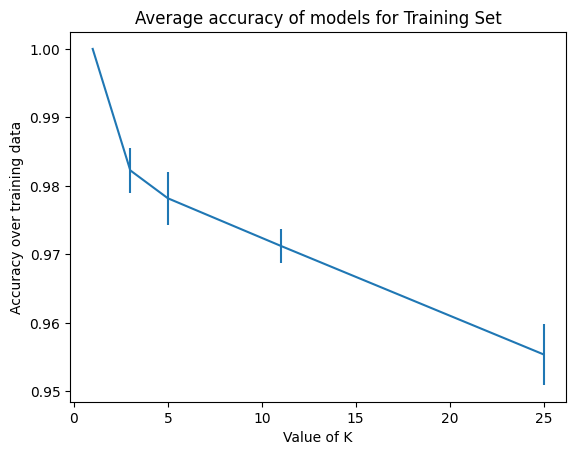

In [ ]:
#Graph for Training
import matplotlib.pyplot as plt
plt.errorbar(NN_values,average_train, yerr=standard_d_train)
plt.ylabel("Accuracy over training data")
plt.xlabel("Value of K")
plt.title("Average accuracy of models for Training Set")

Text(0.5, 1.0, 'Average accuracy of models for Test Set')

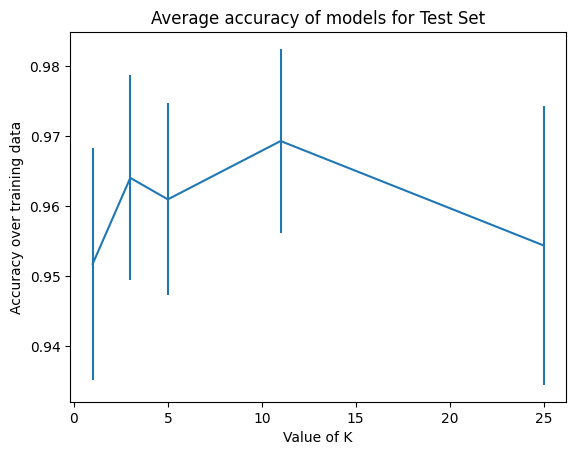

In [ ]:
#Graph for Training
import matplotlib.pyplot as plt
plt.errorbar(NN_values,average_test, yerr=standard_d_test)
plt.ylabel("Accuracy over training data")
plt.xlabel("Value of K")
plt.title("Average accuracy of models for Test Set")

Question: 1.3
Answer: When looking at the Average accuracy of models for Training Set, when k is 1 the training accuracy is almost 100%. This is a classic example of overfitting because each point is it's own nearest neighbor and thus memorizing the data. However this accuracy changes as the value of k increases leading to a gradual decline to 93% when k is 25, because the average takes in more neighbors and is less sensitive to the characteristics of neighborts.

For the second graph, Average accuracy of models for Test Set, its actually the opposite from the Training Set, where when k is 1, the accuracy is at it's lowest. The graph then peaks when k is 11 and then slightly decreases when k is 25. When k is small the model is very senitive and the error bars shows how much the accuracy differs with the shuffles and spitls and it to varies thje largest amount. The model get better around 11, as its making better predictions and has more information and neighbors to gather around it. But then it dips as there are too many k values, thus making the system loose it's accuracy.  

Question: 1.4 Answer: The range of value of k for which k-NN is underfitting would be from 11 to 51 for both reports, as both have a low accuracy and both decline. This suggests that the model is averaging too many neighbors and as a result losing accuracy.

Where it's overfitting occurs on both at k=1 and k=3. Both overfit, but it's worse on the training set. On the training graph the accuracy is close to 100% accurate which indicates just memorization. This memorization affects the test model which is the lowest of the two graphs because of this memorization and this results in poor generalization.

Question: 1.5
Answer: Based on my previous analysis, the value of k that I would select to fine tune this algorithm so that it worked as well as possible in real life would be 11. It avoids overfitting and underfitting, has a great balance for the average of nearest neighbors and produces the average testing accuracy.

Question: 1.6


With the normalization of the features, they are scaled to the same range which makes each of the fields equal to the distance. But without normalization, features with greater values can influence the distance more. The ranges in the dataset aren't extreme so the performance of the two charts looks very similiar which accounts for their similiarity.

In [ ]:
#Libraries
import pandas as pd
import matplotlib as mat
from sklearn.utils import shuffle
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
#Manually Create the k-NN Function

#Defining x_single_row, which is one data point that I want to classify and k is the number of neighbors to use
def knn_function(x_train,y_train, x_single_row, k):
  #Using Euclidean distances
  Euclidean_distances = np.sqrt(np.sum((x_train.values-x_single_row.values)**2, axis = 1))
  #Sort the distances. using the argsort to sort smallest to highest
  sorted_distances = np.argsort(Euclidean_distances)[:k]
  #Get the labels. Uses .iloc to select rows by position
  labels = y_train.iloc[sorted_distances]
  #What is the most common neighbors
  return labels.value_counts().idxmax()

In [ ]:
# Looping over k
NN_values = [1,3,5,11,25]
# Creating empty lists
average_train = []
average_test = []
standard_d_train = []
standard_d_test = []
for k in NN_values:
    train_accuracy = []
    test_accuracy = []
    for run in range(20):
        # Shuffling
        shuffled = shuffle(wdbc_csv)
        # Split
        Wdbc_split = int(0.8 * len(shuffled))
        train_set = shuffled.iloc[:Wdbc_split]
        test_set = shuffled.iloc[Wdbc_split:]
        # Creating the different sets
        x_train = train_set.iloc[:, :30]
        y_train = train_set.iloc[:, 30]
        x_test = test_set.iloc[:, :30]
        y_test = test_set.iloc[:, 30]
        # Training accuracy
        train_predictions = []
        for i in range(len(x_train)):
            prediction = knn_function(x_train, y_train, x_train.iloc[i], k)
            train_predictions.append(prediction)
        train_predictions = np.array(train_predictions)
        accurate_labels = np.sum(train_predictions == y_train.values)
        train_accuracy.append(accurate_labels / len(y_train))
        # Test accuracy
        test_predictions = []
        for i in range(len(x_test)):
            prediction = knn_function(x_train, y_train, x_test.iloc[i], k)
            test_predictions.append(prediction)
        test_predictions = np.array(test_predictions)
        test_accuracy.append(np.sum(test_predictions == y_test.values) / len(y_test))
    # Store averages and std
    average_train.append(np.mean(train_accuracy))
    standard_d_train.append(np.std(train_accuracy))
    average_test.append(np.mean(test_accuracy))
    standard_d_test.append(np.std(test_accuracy))


Text(0.5, 1.0, 'Average accuracy of models for Training Set')

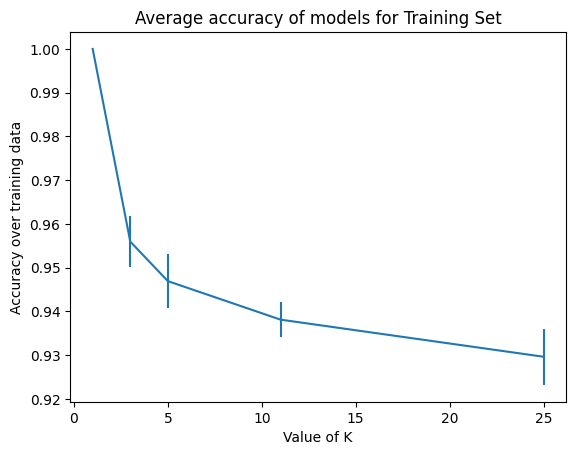

In [ ]:
#Graph for Training
import matplotlib.pyplot as plt
plt.errorbar(NN_values,average_train, yerr=standard_d_train)
plt.ylabel("Accuracy over training data")
plt.xlabel("Value of K")
plt.title("Average accuracy of models for Training Set")

Text(0.5, 1.0, 'Average accuracy of models for Test Set')

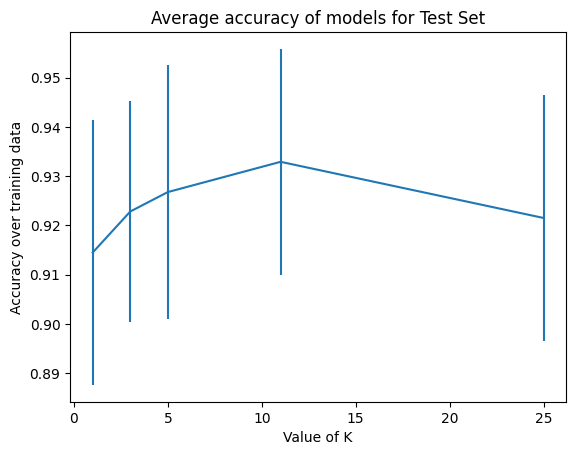

In [ ]:
#Graph for Training
import matplotlib.pyplot as plt
plt.errorbar(NN_values,average_test, yerr=standard_d_test)
plt.ylabel("Accuracy over training data")
plt.xlabel("Value of K")
plt.title("Average accuracy of models for Test Set")

# 2. Evaluating the Decision Tree Algorithm

#Import the data

In [77]:
#Libraries
import pandas as pd
import matplotlib as mat
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter
import math

In [78]:
!git clone https://github.com/nkinsman16/589-Programming-Assignment-1-.git

fatal: destination path '589-Programming-Assignment-1-' already exists and is not an empty directory.


In [79]:
car_csv=pd.read_csv('/content/589-Programming-Assignment-1-/HW1_CMPSCI_589_Spring2026_Supporting_Files/datasets/car.csv')
car_csv.head()



,buying_price,maintenance_price,number_doors,capacity,luggage_boot_size,safety_level,class
0,very_high,very_high,two,two,small,low,unacceptable
1,very_high,very_high,two,two,small,medium,unacceptable
2,very_high,very_high,two,two,small,high,unacceptable
3,very_high,very_high,two,two,medium,low,unacceptable
4,very_high,very_high,two,two,medium,medium,unacceptable


In [80]:

car_x = car_csv.iloc[:, :6]
car_y = car_csv.iloc[:,6]

## Creating Entropy

In [81]:
#Defining the function of Entropy
def car_entropy(Entropy_values):
  #Calculating how many items are in the values
  total = len(Entropy_values)
  #Will count how many times each class appears
  counts = Counter(Entropy_values)
  #Will store the entrophy value
  entropy_value = 0
#Loops through how many unique labels appear
  for count in counts.values():
    #Calculates the probaility the label will apppear by the total
    p = count/total
    #The Entropy formula
    entropy_value -= p* math.log2(p)
#returns final entropy value
  return entropy_value

In [82]:
#Giving Entrophy Information Gain, tells us how useful a attribute is for splitting data
def entropy_IG (data, attribute, target_name):
  #Shows how mixed the dataset is
  total_entropy = car_entropy(data[target_name])
  #Split  the data, one group for sunny, rainy and cloudy
  split = data.groupby(attribute)
  #Looking at the weight entropy. Calcualtes the entropy, multiplies how large the group is and then adds them together
  weight_ent = 0
  for value in data[attribute].unique():
    subset = data[data[attribute]==value]
    weight = len(subset)/len(data)
    weight_ent += weight*car_entropy(subset[target_name])
  #Subtracts gain of before and after
  return total_entropy - weight_ent

## Decision Tree

In [83]:
def decision_tree(data, attributes, target_name):
  # Provides use with what our decision tree is trying to go for
  #need to know what we are trying to classify
  target_values = data[target_name]
  #Identifies if all names are unique
  #Len() counts how many and returns unique values
  if len(target_values.unique()) == 1:
    #use iloc[0] to get first value in column
    return target_values.iloc[0]
#If there are no more splits, return the most common
  if len(attributes) == 0:
    #mode returns the most common value
    most_common = target_values.mode()[0]
    return most_common
#Find the best attribute:
#create a place holder
  best_attribute = None
  #guarantees the first real information gain, greater or equal to 0
  best_gain= -1
  #loops through each attribute
  for attribute in attributes:
    #Create a function that measures entropy reduction
    gain = entropy_IG(data, attribute, target_name)
    #Makes sure the attribute with largest Information gain is chosen
    if gain > best_gain:
      best_gain = gain
      best_attribute = attribute
#Create a  tree node
#Creates a dictionary, a key value structure
  tree = {best_attribute:{}}
  #Get all values of the best attribute
  attribute_values = data[best_attribute].unique()
  #Creates a smaller dataset for each branch
  for value in attribute_values:
    #Creating a smaller dataset for each of the new branches
    subset = data[data[best_attribute] == value]
    #If the subset is empty, take the majority
    if len(subset) == 0:
      #PRevents errors and ensures something
      majority_class = target_values.mode()[0]
      tree[best_attribute][value]=majority_class
    else:
        #take out the used attributes from the list and keep only the best
        remaining_attributes = []
        # Loops through each item inside the list
        remaining_attributes = [attr for attr in attributes if attr != best_attribute]
        subtree = decision_tree(subset, remaining_attributes, target_name)
        tree[best_attribute][value] = subtree
  return tree

In [84]:
#Defining a new function "classify",
def classify (tree, instance):
  #Points to where on the tree the analysis is
  current_node = tree
  #Repeats a block of code until false, "isinstance" checks whether x is a dictionary
  #If it's a dict, then yes or no, descion nodes are dictionaries
  while isinstance(current_node, dict):
    #Returns all keys in teh dictionary, converts keys to list
    #[0] takes the first key
    #attribute is what's being tested
    attribute = list(current_node.keys())[0]
    #Instance gets the value from the sample for a given column
    sample_value = instance[attribute]
    #dictionary branches, checks to see if the value matches the branches
    if sample_value in current_node[attribute]:
      #current Node: updates the position of the tree
      #j[sample_value] to pick the branch the matches sample best
      current_node = current_node[attribute][sample_value]
    else:
      #Returns no predictions
        return None

  return current_node


In [85]:
# Ensuring Accuracy
#Tree: trained decision tree model, data: dataset, target_name: name of the column of correct names
def accuracy (tree, data, target_name):
  #How many predictions are correct. Starts at zero
  correct = 0
  # iterrows: pandas function that returns each row one at a time
  for index, row in data.iterrows():
    # Find the correct name of the current row
    correct_value = row[target_name]
    #Uses the decision tree to predict the label
    predicted_value = classify(tree, row)
#Chek to see if the prediction matches the real answer
    if predicted_value == correct_value:
      #If correct adds to the counter
      correct = correct +1
  return correct/len(data)

## Let's Plant a tree

In [95]:
target_name = car_csv.columns[6]
attributes = list(car_csv.columns[:6])

train_accuracies = []
test_accuracies = []

for i in range (100):
  cars_csv_shuffled = shuffle(car_csv)
  split_index = int(0.8*len(cars_csv_shuffled))
  training_data = cars_csv_shuffled.iloc[:split_index]
  testing_data = cars_csv_shuffled.iloc[split_index:]
  tree = decision_tree(training_data, attributes, target_name)
  train_accuracy = accuracy(tree, training_data, target_name)
  test_accuracy = accuracy(tree, testing_data, target_name)

  train_accuracies.append(train_accuracy)
  test_accuracies.append(test_accuracy)
  mean_train=np.mean(train_accuracies)
  mean_test=np.mean(test_accuracies)
  std_train=np.std(train_accuracies)
  std_test=np.std(test_accuracies)


## Graphs

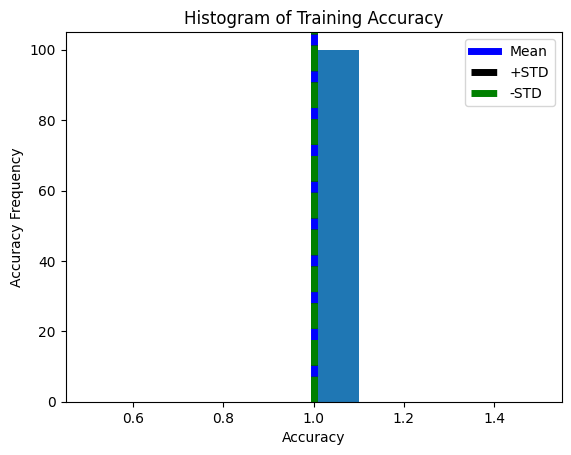

In [112]:
plt.figure()
plt.hist(train_accuracies, bins=10)
#mean
plt.axvline(mean_train, color='b', linestyle='solid', linewidth=5, label = "Mean")
#Stand deviation lines
plt.axvline(mean_train + std_train, color='k', linestyle='dashed', linewidth=5, label = "+STD")
plt.axvline(mean_train - std_train, color='g', linestyle='dashed', linewidth=5, label = "-STD")
plt.xlabel("Accuracy")
plt.ylabel("Accuracy Frequency")
plt.title("Histogram of Training Accuracy")
plt.legend(loc="best")
plt.show()

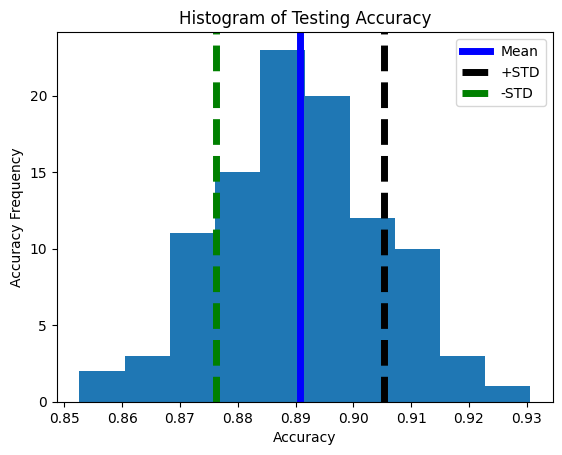

In [113]:
plt.figure()
plt.hist(test_accuracies, bins=10)
#mean
plt.axvline(mean_test, color='b', linestyle='solid', linewidth=5, label = "Mean")
#Stand deviation lines
plt.axvline(mean_test + std_test, color='k', linestyle='dashed', linewidth=5, label = "+STD")
plt.axvline(mean_test - std_test, color='g', linestyle='dashed', linewidth=5, label = "-STD")
plt.xlabel("Accuracy")
plt.ylabel("Accuracy Frequency")
plt.title("Histogram of Testing Accuracy")
plt.legend(loc="best")
plt.show()

#Extra Credit

In [117]:
#Libraries
import pandas as pd
import matplotlib as mat
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter
import math

In [118]:
#Defining the function of Entropy
def car_entropy(Entropy_values):
  #Calculating how many items are in the values
  total = len(Entropy_values)
  #Will count how many times each class appears
  counts = Counter(Entropy_values)
  #Will store the entrophy value
  entropy_value = 0
#Loops through how many unique labels appear
  for count in counts.values():
    #Calculates the probaility the label will apppear by the total
    p = count/total
    #The Entropy formula
    entropy_value -= p* math.log2(p)
#returns final entropy value
  return entropy_value

In [119]:
#Defining the Gini Function
def gini(gini_values):
  #Calculating how many items are in the values
  total = len(gini_values)
  counts = Counter(gini_values)
  gini_value = 1
  for  count in counts.values():
    p = count/total
    gini_value -= p**2
  return gini_value

In [120]:
#Gini Split Function
def gini_IG (data, attribute, target_name):
  total_gini = gini(data[target_name])
  weighted_mode = 0

  for value in data[attribute].unique():
    subset = data[data[attribute]==value]
    weight = len(subset)/len(data)
    weighted_mode += weight*gini(subset[target_name])
  return total_gini - weighted_mode

In [121]:
#Giving Entrophy Information Gain, tells us how useful a attribute is for splitting data
def entropy_IG (data, attribute, target_name):
  #Shows how mixed the dataset is
  total_entropy = car_entropy(data[target_name])
  #Split  the data, one group for sunny, rainy and cloudy
  split = data.groupby(attribute)
  #Looking at the weight entropy. Calcualtes the entropy, multiplies how large the group is and then adds them together
  weight_ent = 0
  for value in data[attribute].unique():
    subset = data[data[attribute]==value]
    weight = len(subset)/len(data)
    weight_ent += weight*car_entropy(subset[target_name])
  #Subtracts gain of before and after
  return total_entropy - weight_ent

In [122]:
def decision_tree(data, attributes, target_name):
  # Provides use with what our decision tree is trying to go for
  #need to know what we are trying to classify
  target_values = data[target_name]
  #Identifies if all names are unique
  #Len() counts how many and returns unique values
  if len(target_values.unique()) == 1:
    #use iloc[0] to get first value in column
    return target_values.iloc[0]
#If there are no more splits, return the most common
  if len(attributes) == 0:
    #mode returns the most common value
    most_common = target_values.mode()[0]
    return most_common
#Find the best attribute:
#create a place holder
  best_attribute = None
  #guarantees the first real information gain, greater or equal to 0
  best_gain= -1
  #loops through each attribute
  for attribute in attributes:
    #Create a function that measures entropy reduction
    gain = gini_IG(data, attribute, target_name)
    #Makes sure the attribute with largest Information gain is chosen
    if gain > best_gain:
      best_gain = gain
      best_attribute = attribute
#Create a  tree node
#Creates a dictionary, a key value structure
  tree = {best_attribute:{}}
  #Get all values of the best attribute
  attribute_values = data[best_attribute].unique()
  #Creates a smaller dataset for each branch
  for value in attribute_values:
    #Creating a smaller dataset for each of the new branches
    subset = data[data[best_attribute] == value]
    #If the subset is empty, take the majority
    if len(subset) == 0:
      #PRevents errors and ensures something
      majority_class = target_values.mode()[0]
      tree[best_attribute][value]=majority_class
    else:
        #take out the used attributes from the list and keep only the best
        remaining_attributes = []
        # Loops through each item inside the list
        remaining_attributes = [attr for attr in attributes if attr != best_attribute]
        subtree = decision_tree(subset, remaining_attributes, target_name)
        tree[best_attribute][value] = subtree
  return tree

In [123]:
#Defining a new function "classify",
def classify (tree, instance):
  #Points to where on the tree the analysis is
  current_node = tree
  #Repeats a block of code until false, "isinstance" checks whether x is a dictionary
  #If it's a dict, then yes or no, descion nodes are dictionaries
  while isinstance(current_node, dict):
    #Returns all keys in teh dictionary, converts keys to list
    #[0] takes the first key
    #attribute is what's being tested
    attribute = list(current_node.keys())[0]
    #Instance gets the value from the sample for a given column
    sample_value = instance[attribute]
    #dictionary branches, checks to see if the value matches the branches
    if sample_value in current_node[attribute]:
      #current Node: updates the position of the tree
      #j[sample_value] to pick the branch the matches sample best
      current_node = current_node[attribute][sample_value]
    else:
      #Returns no predictions
        return None

  return current_node


In [124]:
# Ensuring Accuracy
#Tree: trained decision tree model, data: dataset, target_name: name of the column of correct names
def accuracy (tree, data, target_name):
  #How many predictions are correct. Starts at zero
  correct = 0
  # iterrows: pandas function that returns each row one at a time
  for index, row in data.iterrows():
    # Find the correct name of the current row
    correct_value = row[target_name]
    #Uses the decision tree to predict the label
    predicted_value = classify(tree, row)
#Chek to see if the prediction matches the real answer
    if predicted_value == correct_value:
      #If correct adds to the counter
      correct = correct +1
  return correct/len(data)

In [125]:
target_name = car_csv.columns[6]
attributes = list(car_csv.columns[:6])

train_accuracies = []
test_accuracies = []

for i in range (100):
  cars_csv_shuffled = shuffle(car_csv)
  split_index = int(0.8*len(cars_csv_shuffled))
  training_data = cars_csv_shuffled.iloc[:split_index]
  testing_data = cars_csv_shuffled.iloc[split_index:]
  tree = decision_tree(training_data, attributes, target_name)
  train_accuracy = accuracy(tree, training_data, target_name)
  test_accuracy = accuracy(tree, testing_data, target_name)

  train_accuracies.append(train_accuracy)
  test_accuracies.append(test_accuracy)
  mean_train=np.mean(train_accuracies)
  mean_test=np.mean(test_accuracies)
  std_train=np.std(train_accuracies)
  std_test=np.std(test_accuracies)


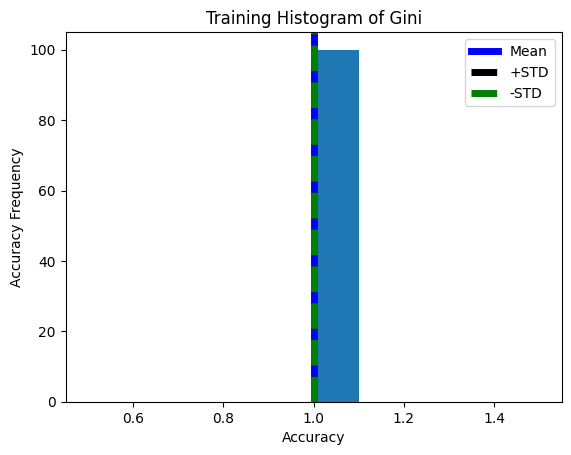

In [128]:
plt.figure()
plt.hist(train_accuracies, bins=10)
#mean
plt.axvline(mean_train, color='b', linestyle='solid', linewidth=5, label = "Mean")
#Stand deviation lines
plt.axvline(mean_train + std_train, color='k', linestyle='dashed', linewidth=5, label = "+STD")
plt.axvline(mean_train - std_train, color='g', linestyle='dashed', linewidth=5, label = "-STD")
plt.xlabel("Accuracy")
plt.ylabel("Accuracy Frequency")
plt.title("Training Histogram of Gini")
plt.legend(loc="best")
plt.show()

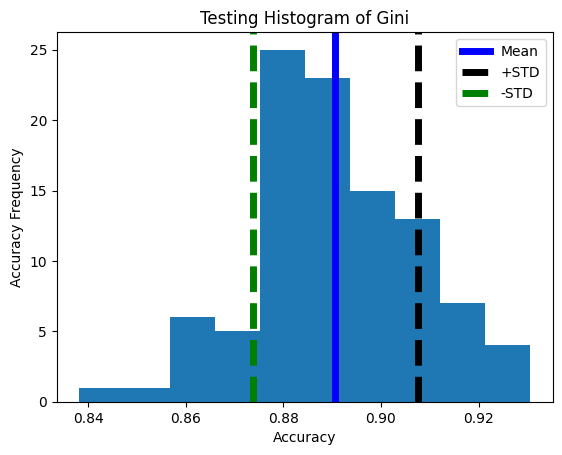

In [130]:
plt.figure()
plt.hist(test_accuracies, bins=10)
#mean
plt.axvline(mean_test, color='b', linestyle='solid', linewidth=5, label = "Mean")
#Stand deviation lines
plt.axvline(mean_test + std_test, color='k', linestyle='dashed', linewidth=5, label = "+STD")
plt.axvline(mean_test - std_test, color='g', linestyle='dashed', linewidth=5, label = "-STD")
plt.xlabel("Accuracy")
plt.ylabel("Accuracy Frequency")
plt.title("Testing Histogram of Gini")
plt.legend(loc="best")
plt.show()